# Import required libraries

In [1]:
import cv2
import os
import numpy as np
import json
import matplotlib.pyplot as plt
import shutil
import pandas as pd
import seaborn as sns
from PIL import Image
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Initialise image data generator and normalise

In [6]:
train_data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_data_gen = ImageDataGenerator(rescale=1./255)


# Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

!mkdir {HOME}/datasets
%cd {HOME}/datasets

!unzip /content/gdrive/MyDrive/emotion.zip

Streaming output truncated to the last 5000 lines.
  inflating: emotion/train/angry/Training_81541574.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_81541574.jpg  
  inflating: emotion/train/angry/Training_50120123.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_50120123.jpg  
  inflating: emotion/train/angry/Training_60016886.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_60016886.jpg  
  inflating: emotion/train/angry/Training_68690730.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_68690730.jpg  
  inflating: emotion/train/angry/Training_73515932.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_73515932.jpg  
  inflating: emotion/train/angry/Training_32153813.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_32153813.jpg  
  inflating: emotion/train/angry/Training_57743136.jpg  
  inflating: __MACOSX/emotion/train/angry/._Training_57743136.jpg  
  inflating: emotion/train/angry/Training_15933141.jpg  
  inflating: __MA

# Clean Dataset

In [ ]:
!find datasets/emotion/train -type f | head -10  # Check first 10 files
!file datasets/emotion/train/*/* | grep -v "image data"  # Find non-image files

datasets/emotion/train/happy/Training_50449107.jpg
datasets/emotion/train/happy/Training_70433018.jpg
datasets/emotion/train/happy/Training_85610005.jpg
datasets/emotion/train/happy/Training_4460748.jpg
datasets/emotion/train/happy/Training_6312930.jpg
datasets/emotion/train/happy/Training_25740534.jpg
datasets/emotion/train/happy/Training_80076077.jpg
datasets/emotion/train/happy/Training_431681.jpg
datasets/emotion/train/happy/Training_76432922.jpg
datasets/emotion/train/happy/Training_53152280.jpg
find: stdout: Undefined error: 0
/bin/bash: /usr/bin/file: Argument list too long


In [ ]:
def clean_dataset(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            try:
                img_path = os.path.join(root, file)
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, SyntaxError) as e:
                print(f'Removing corrupt file: {img_path}')
                os.remove(img_path)

clean_dataset('datasets/emotion/train')
clean_dataset('datasets/emotion/val')

Removing corrupt file: datasets/emotion/train/.DS_Store
Removing corrupt file: datasets/emotion/val/.DS_Store


# Load and preprocess dataset

In [ ]:
# Create data generator
train_generator = train_data_gen.flow_from_directory(
	'/content/emotion/train',
	target_size=(48, 48),
	batch_size=64,
	color_mode="grayscale",
	class_mode='categorical')

validation_generator = val_data_gen.flow_from_directory(
        '/content/emotion/val',
        target_size=(48, 48),
        batch_size=64,
        color_mode="grayscale",
        class_mode='categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [7]:
def Classes_Count( path, name):
    Classes_Dict = {}

    for Class in os.listdir(path):

        Full_Path = os.path.join(path, Class)
        Classes_Dict[Class] = len(os.listdir(Full_Path))

    df = pd.DataFrame(Classes_Dict, index=[name])

    return df

Train_Count = Classes_Count('/content/emotion/train',"train").transpose().sort_values(by="train", ascending=False)
Val_Count = Classes_Count('/content/emotion/val', 'val').transpose().sort_values(by="val", ascending=False)

pd.concat([Train_Count,Val_Count] , axis=1)

,train,val
happy,7215,1774
neutral,4965,1233
sad,4830,1247
fear,4097,1024
angry,3995,958
surprise,3171,831
disgust,436,111


<Axes: >

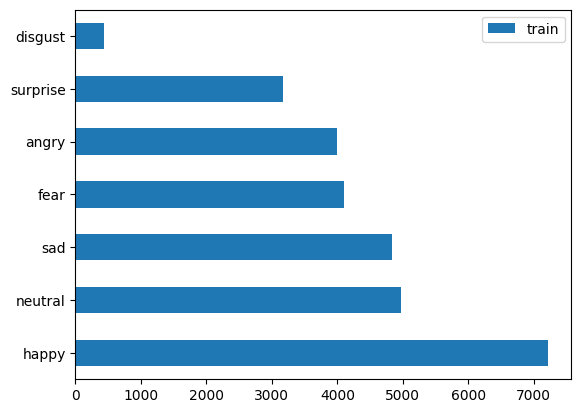

In [ ]:
Train_Count.plot(kind='barh')

<Axes: >

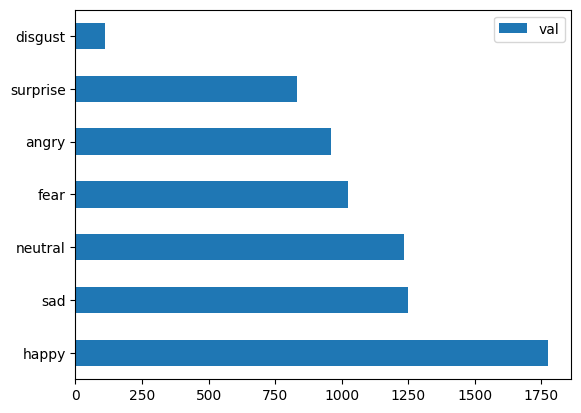

In [ ]:
Val_Count.plot(kind='barh')

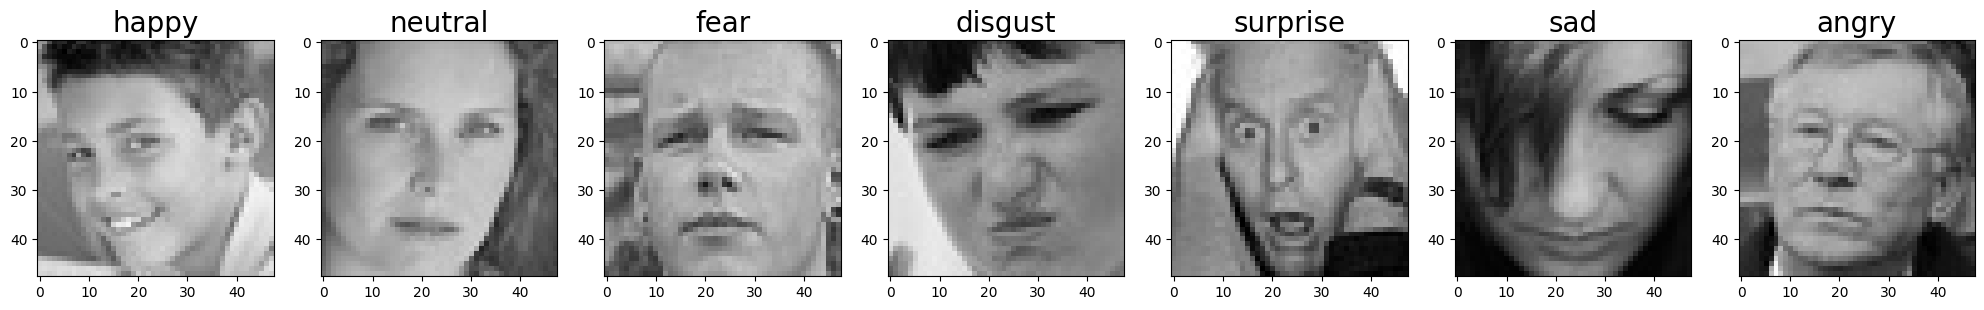

In [ ]:
plt.style.use('default')
plt.figure(figsize = (25, 8))
image_count = 1

for directory in os.listdir('/content/emotion/train'):
    if directory[0] != '.':
        class_path = os.path.join('/content/emotion/train', directory)
        for i, file in enumerate(os.listdir(class_path)):
            if i == 1:
                break
            else:
                fig = plt.subplot(1, 7, image_count)
                image_count += 1
                image_path = os.path.join(class_path, file)
                image = cv2.imread(image_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # optional, for correct color display
                plt.imshow(image)
                plt.title(directory, fontsize=20)

# Create CNN Model Structure

In [ ]:
# Define the input
inputs = Input(shape=(48, 48, 1))

# Block 1
x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001))(inputs) # Apply L2 regularization to the kernel weights
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Block 3
x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

# Global Pooling and Dense layers
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(7, activation='softmax')(x)

# Define the model
emotion_model = Model(inputs=inputs, outputs=outputs)

print(emotion_model.summary())


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 624,327 (2.38 MB)

 Trainable params: 623,047 (2.38 MB)

 Non-trainable params: 1,280 (5.00 KB)

None


# Compile The Model

In [ ]:
optimizer = Adam(learning_rate=0.001)

emotion_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1) # Dynamically reduce learning rate when improvement stalls

# Train The Neural Network

In [ ]:
emotion_model_info = emotion_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    epochs=50,
    callbacks=[early_stopping, lr_scheduler]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.2241 - loss: 1.8876 - val_accuracy: 0.1709 - val_loss: 2.0817 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.2839 - loss: 1.7517 - val_accuracy: 0.3066 - val_loss: 1.7225 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.3632 - loss: 1.6025 - val_accuracy: 0.3874 - val_loss: 1.5767 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 44s 68ms/step - accuracy: 0.4301 - loss: 1.4664 - val_accuracy: 0.4925 - val_loss: 1.3284 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.4821 - loss: 1.3599 - val_accuracy: 0.5106 - val_loss: 1.2797 - learning_rate: 0.0010
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.5010 - loss: 1.3119 - val_accuracy: 0.4975 - val_loss: 1.2824 - learning_rate: 0.0010
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.5166 - l

# Accuracy and Loss Evaluation

In [ ]:
loss, accuracy = emotion_model.evaluate(validation_generator)

print(loss)
print(accuracy)

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6501 - loss: 0.9413
0.9457476735115051
0.6522708535194397


# Visualising accuracy and loss

In [ ]:
accuracy = emotion_model_info.history['accuracy']
val_accuracy = emotion_model_info.history['val_accuracy']
loss = emotion_model_info.history['loss']
val_loss = emotion_model_info.history['val_loss']


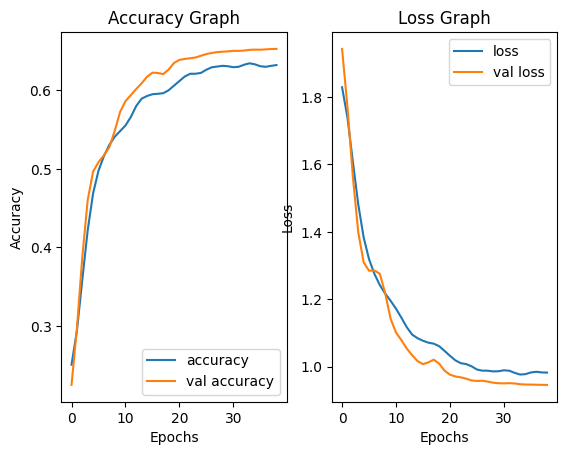

In [ ]:
smooth_accuracy = gaussian_filter1d(accuracy, sigma=1)
smooth_val_accuracy = gaussian_filter1d(val_accuracy, sigma=1)
smooth_loss = gaussian_filter1d(loss, sigma=1)
smooth_val_loss = gaussian_filter1d(val_loss, sigma=1)

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(smooth_accuracy, label='accuracy')
plt.plot(smooth_val_accuracy, label='val accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(smooth_loss, label='loss')
plt.plot(smooth_val_loss, label='val loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


# Save model and training history

In [ ]:
# Ensure the directory exists
os.makedirs('models', exist_ok=True)

emotion_model.save('models/emotion_model.h5')

with open('models/emotion_training_history.json', 'w') as f:
    json.dump(emotion_model_info.history, f)


In [ ]:
from google.colab import files

folder_path = 'models'

shutil.make_archive(folder_path, 'zip', folder_path)

files.download(folder_path + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model Evaluation

In [18]:
# Load model
emotion_model = load_model('models/emotion_model_base.h5')

In [4]:
# Load model training history
with open('base_training_history.json', 'r') as f:
    emotion_model_info_history = json.load(f)

In [ ]:
# Predict class probabilities
y_pred_probs = emotion_model.predict(validation_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred, target_names=class_labels))


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


113/113 ━━━━━━━━━━━━━━━━━━━━ 88s 769ms/step
              precision    recall  f1-score   support

       angry       0.14      0.15      0.14       958
     disgust       0.03      0.01      0.01       111
        fear       0.14      0.09      0.11      1024
       happy       0.25      0.25      0.25      1774
     neutral       0.17      0.22      0.19      1233
         sad       0.17      0.17      0.17      1247
    surprise       0.11      0.12      0.12       831

    accuracy                           0.18      7178
   macro avg       0.14      0.14      0.14      7178
weighted avg       0.17      0.18      0.17      7178



113/113 ━━━━━━━━━━━━━━━━━━━━ 89s 792ms/step


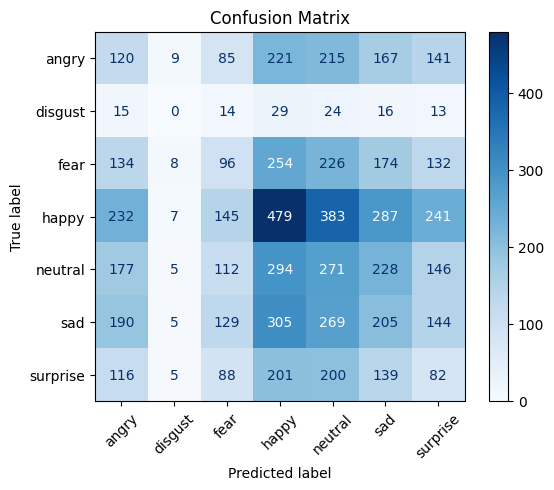

In [ ]:
# Get the true labels and predicted labels for the validation set
validation_true_labels = validation_generator.classes
validation_pred_probs = emotion_model.predict(validation_generator)
validation_pred_labels = np.argmax(validation_pred_probs, axis=1)

# Compute the confusion matrix
matrix = confusion_matrix(validation_true_labels, validation_pred_labels)
class_labels = list(train_generator.class_indices.keys())
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step


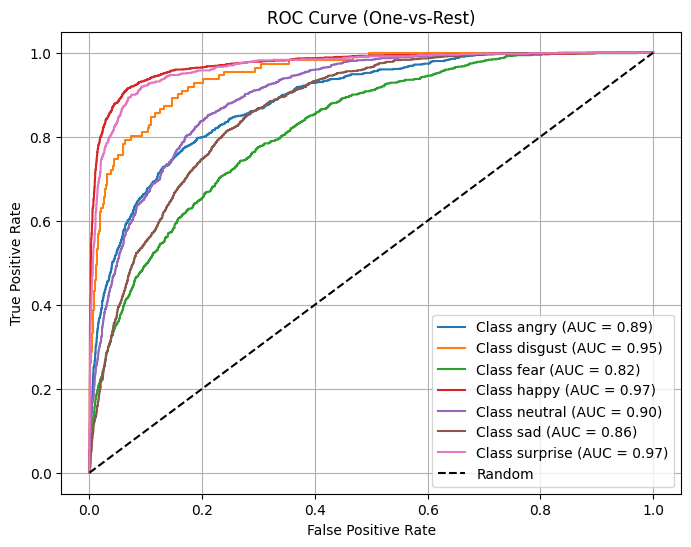

In [19]:
n_val_samples = validation_generator.samples
n_classes = validation_generator.num_classes

# Extract all data from the generator
# Set steps to cover the full dataset
X_test, y_test_onehot = [], []

for i in range(int(np.ceil(n_val_samples / validation_generator.batch_size))):
    x_batch, y_batch = next(validation_generator)
    X_test.append(x_batch)
    y_test_onehot.append(y_batch)

# Concatenate all batches
X_test = np.concatenate(X_test)
y_test_onehot = np.concatenate(y_test_onehot)

# Convert one-hot labels to class indices (e.g., 0–6)
y_test = np.argmax(y_test_onehot, axis=1)

y_pred_probs = emotion_model.predict(X_test)  # shape: (n_samples, n_classes)

# --- 4. Binarize the true labels ---
n_classes = y_pred_probs.shape[1]
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# --- 5. Compute ROC curves and AUCs ---
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 6. Plot ROC curves ---
class_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

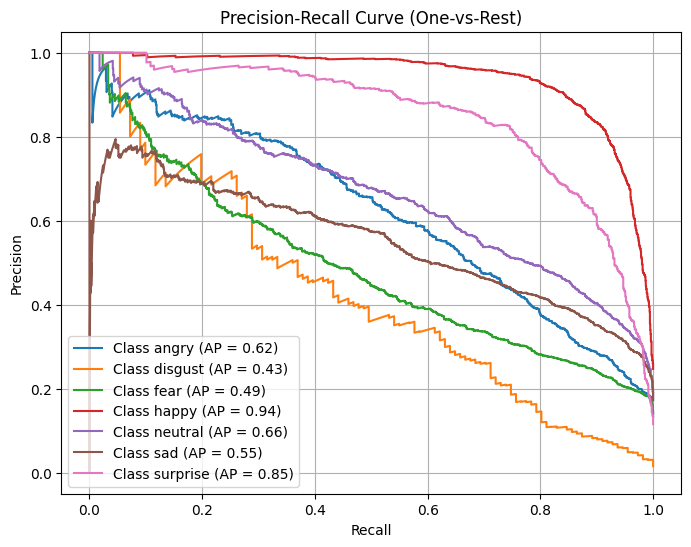

In [ ]:
# Compute Precision-Recall curves and average precision
precision = {}
recall = {}
avg_precision = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    avg_precision[i] = average_precision_score(y_test_bin[:, i], y_pred_probs[:, i])

# Plot Precision-Recall curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Class {class_labels[i]} (AP = {avg_precision[i]:.2f})')

plt.title('Precision-Recall Curve (One-vs-Rest)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


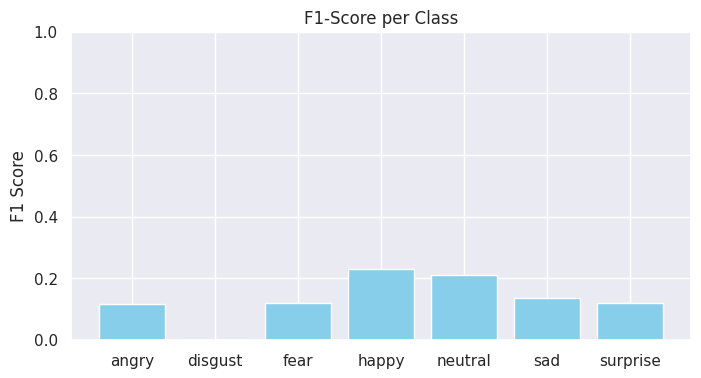

In [ ]:
# Compute F1-score for each class
f1 = f1_score(y_true, y_pred, average=None)

# Plot F1-score per class
plt.figure(figsize=(8, 4))
plt.bar(class_labels, f1, color='skyblue')
plt.title('F1-Score per Class')
plt.ylabel('F1 Score')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()


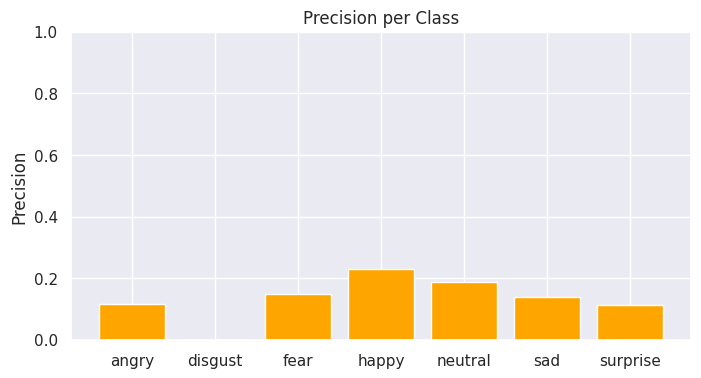

In [ ]:
# Compute precision for each class
precision_scores = precision_score(y_true, y_pred, average=None)

plt.figure(figsize=(8, 4))
plt.bar(class_labels, precision_scores, color='orange')
plt.title('Precision per Class')
plt.ylabel('Precision')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()


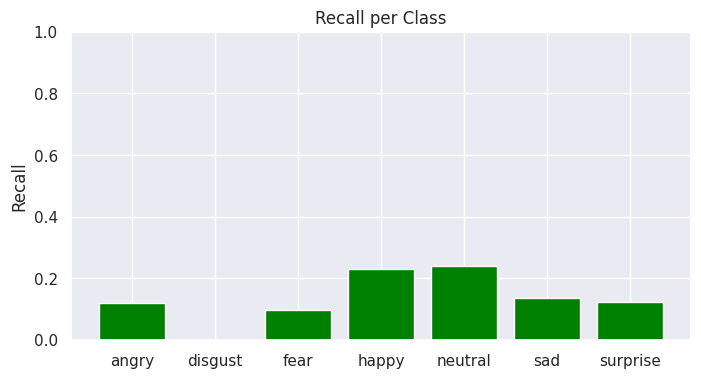

In [ ]:
# Compute recall for each class
recall_scores = recall_score(y_true, y_pred, average=None)

plt.figure(figsize=(8, 4))
plt.bar(class_labels, recall_scores, color='green')
plt.title('Recall per Class')
plt.ylabel('Recall')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


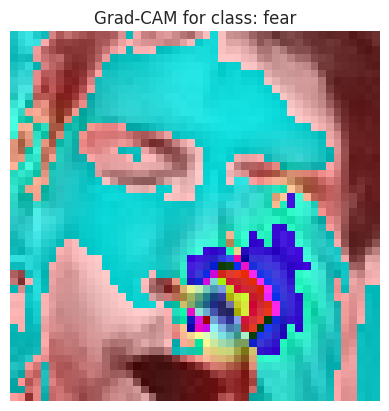

In [ ]:
# Get image from validation generator
img, label = next(validation_generator)
img_input = img[0][np.newaxis, ...]  # Single image

# Get model's prediction
pred_index = np.argmax(emotion_model.predict(img_input))

emotion_model.predict(np.zeros((1, 48, 48, 1)))

# Grad-CAM logic
grad_model = Model([emotion_model.inputs], [emotion_model.get_layer(index=-6).output, emotion_model.output])
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_input)
    loss = predictions[:, pred_index]

grads = tape.gradient(loss, conv_outputs)[0]
weights = tf.reduce_mean(grads, axis=(0, 1))
cam = np.zeros(conv_outputs.shape[1:3], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * conv_outputs[0, :, :, i]

cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (48, 48))
cam = cam / cam.max()

# Overlay heatmap on image
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = heatmap * 0.4 + np.uint8(img[0] * 255)

plt.imshow(overlay.astype(np.uint8))
plt.title(f"Grad-CAM for class: {class_labels[pred_index]}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step


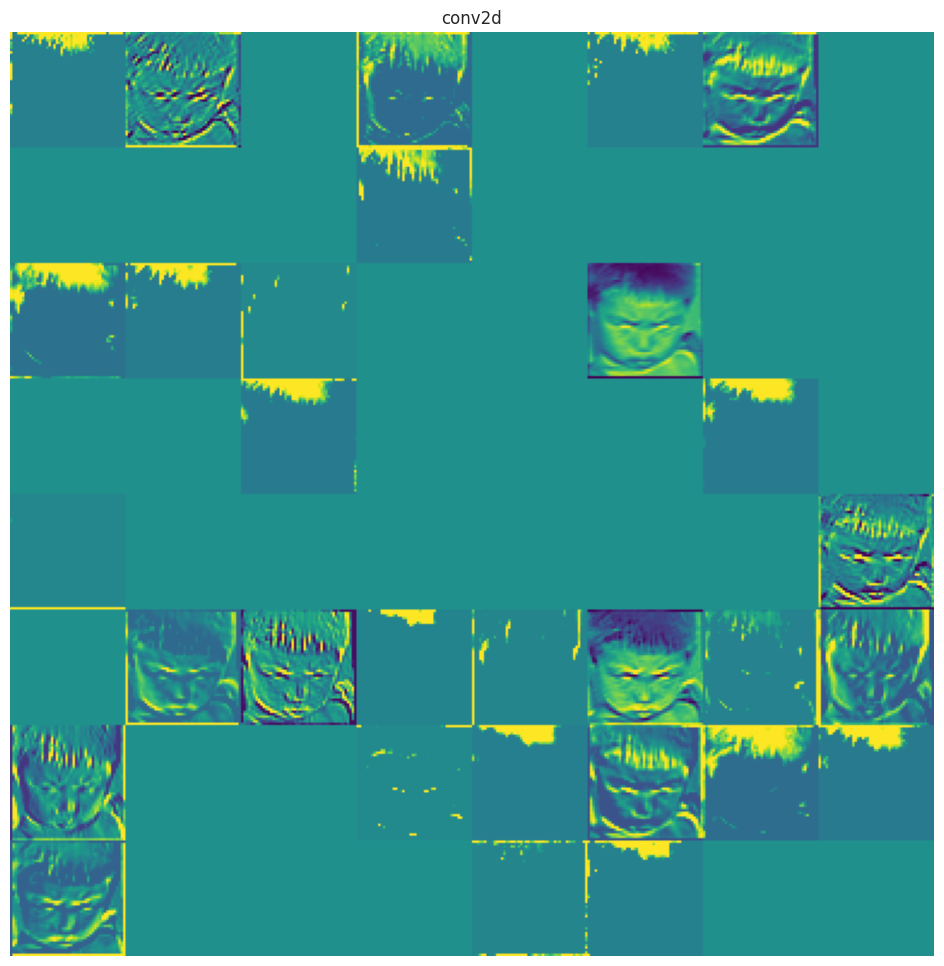

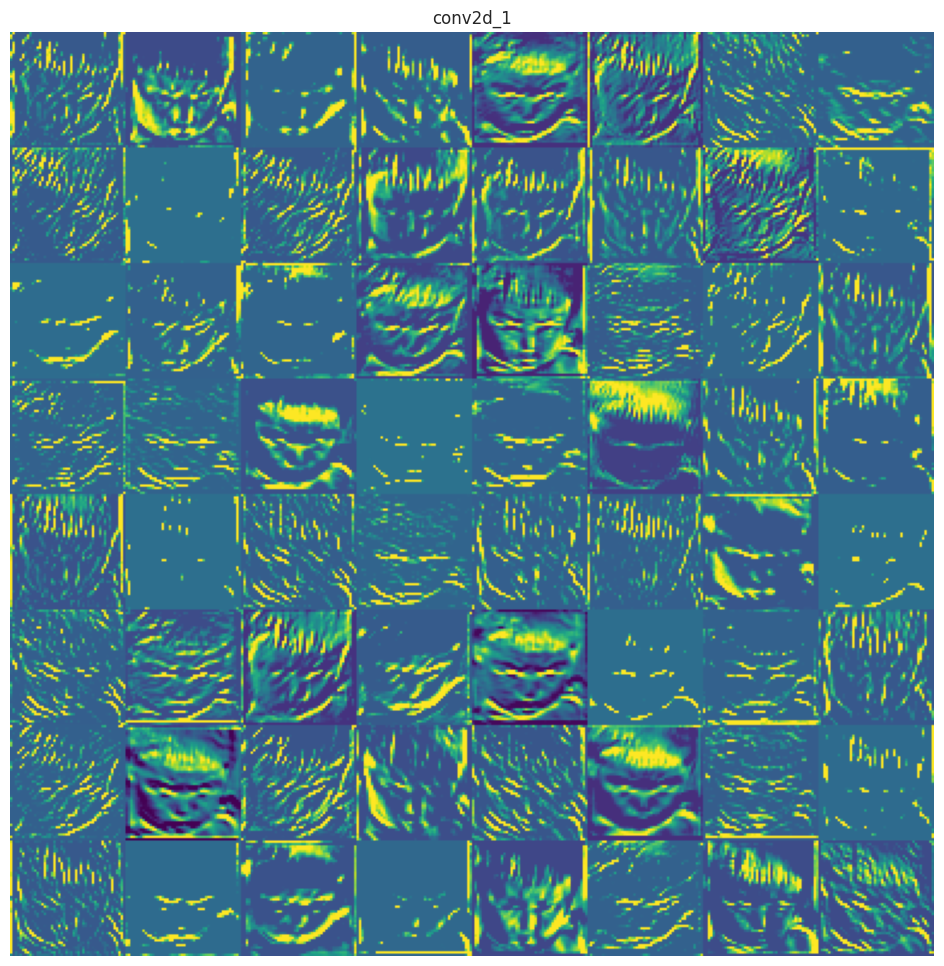

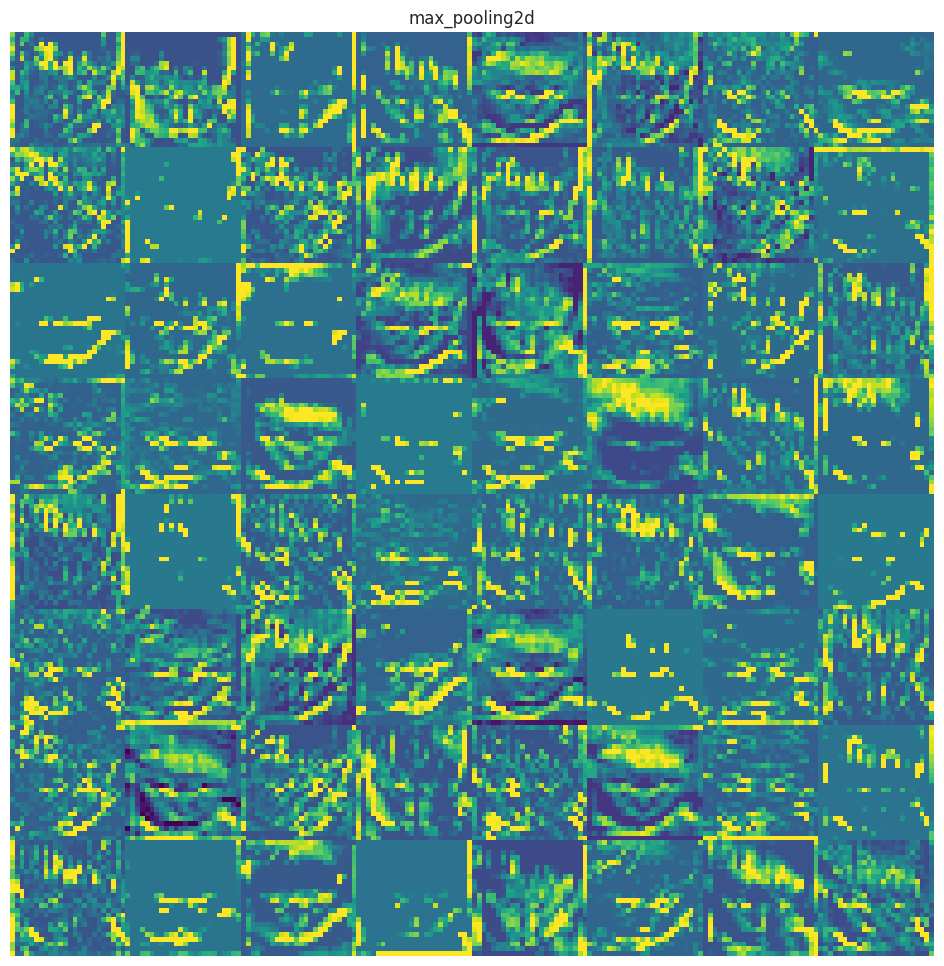

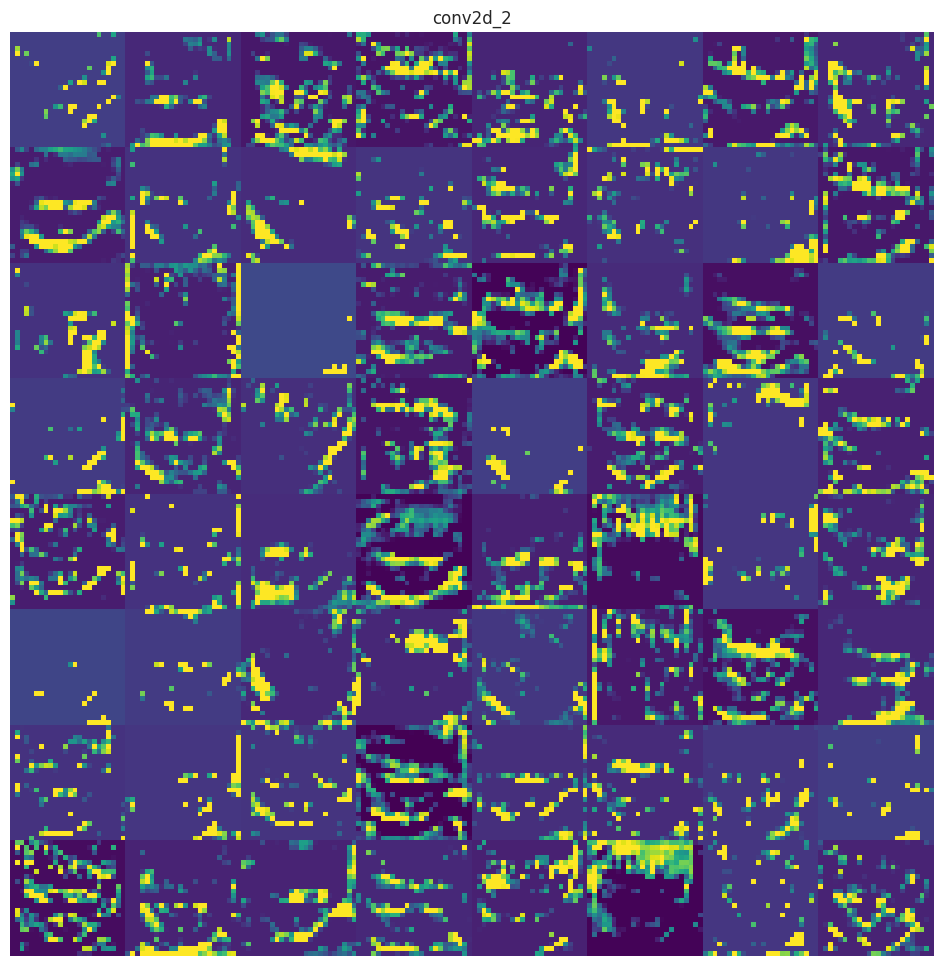

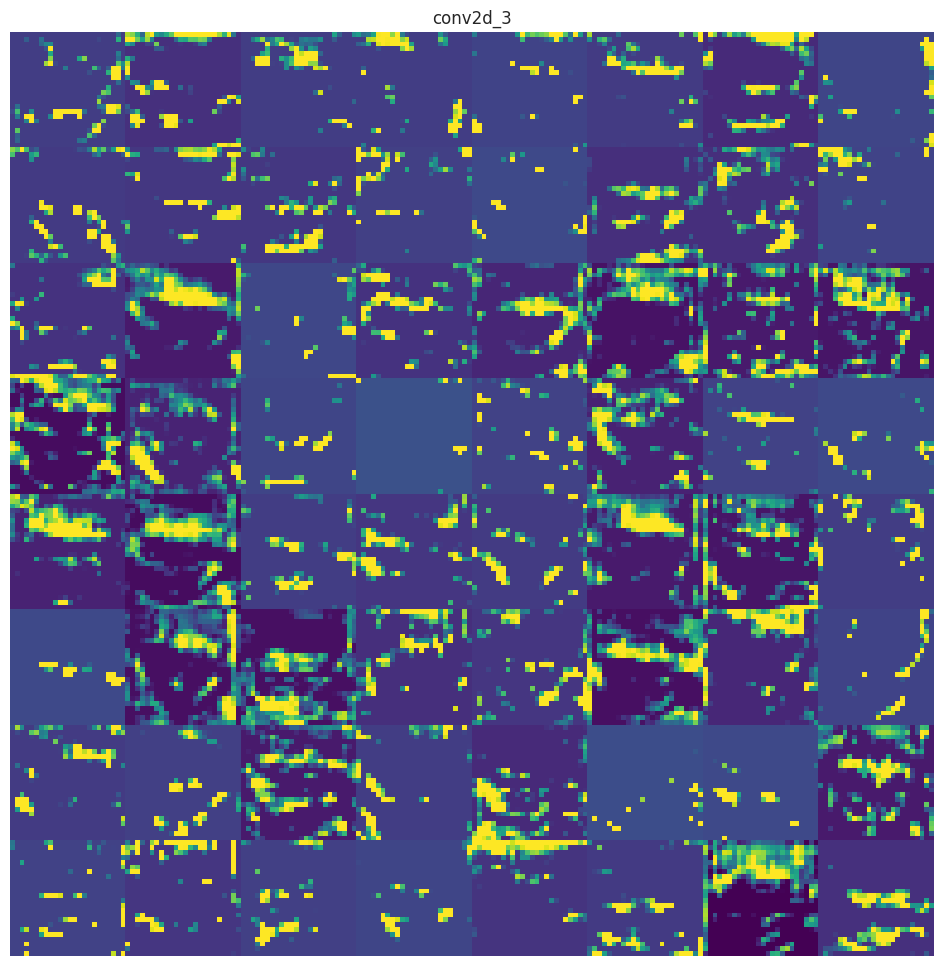

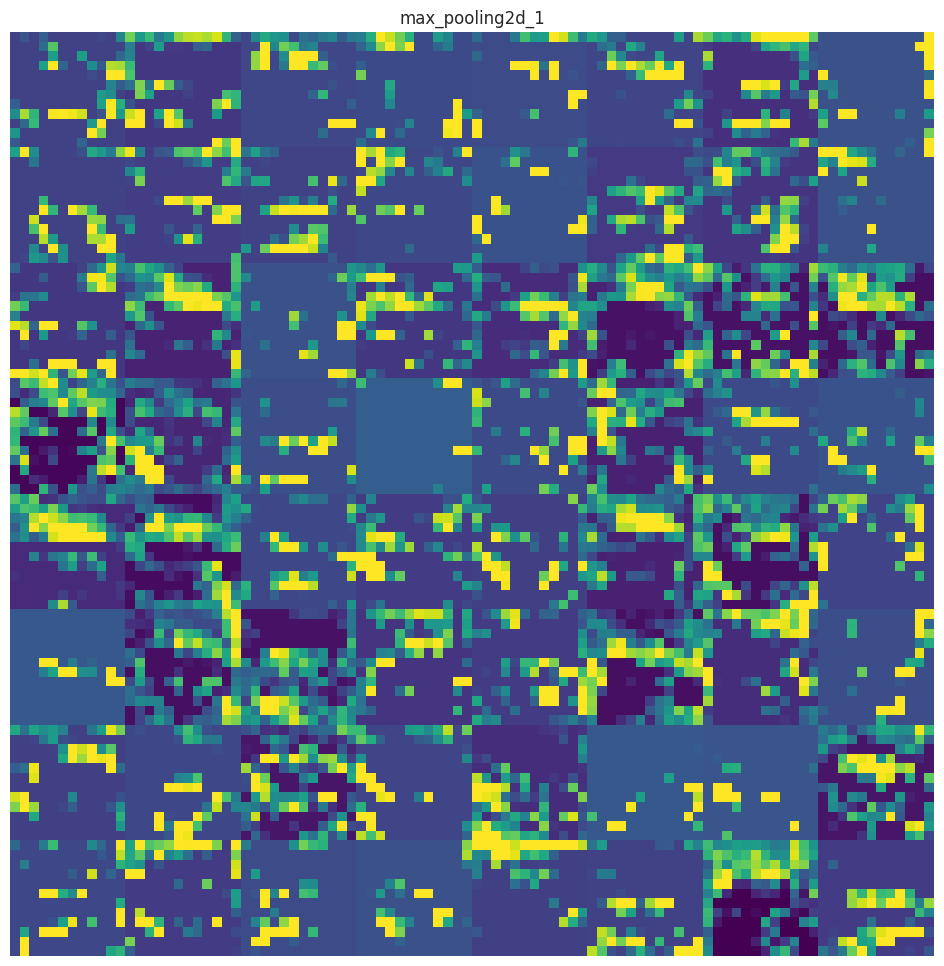

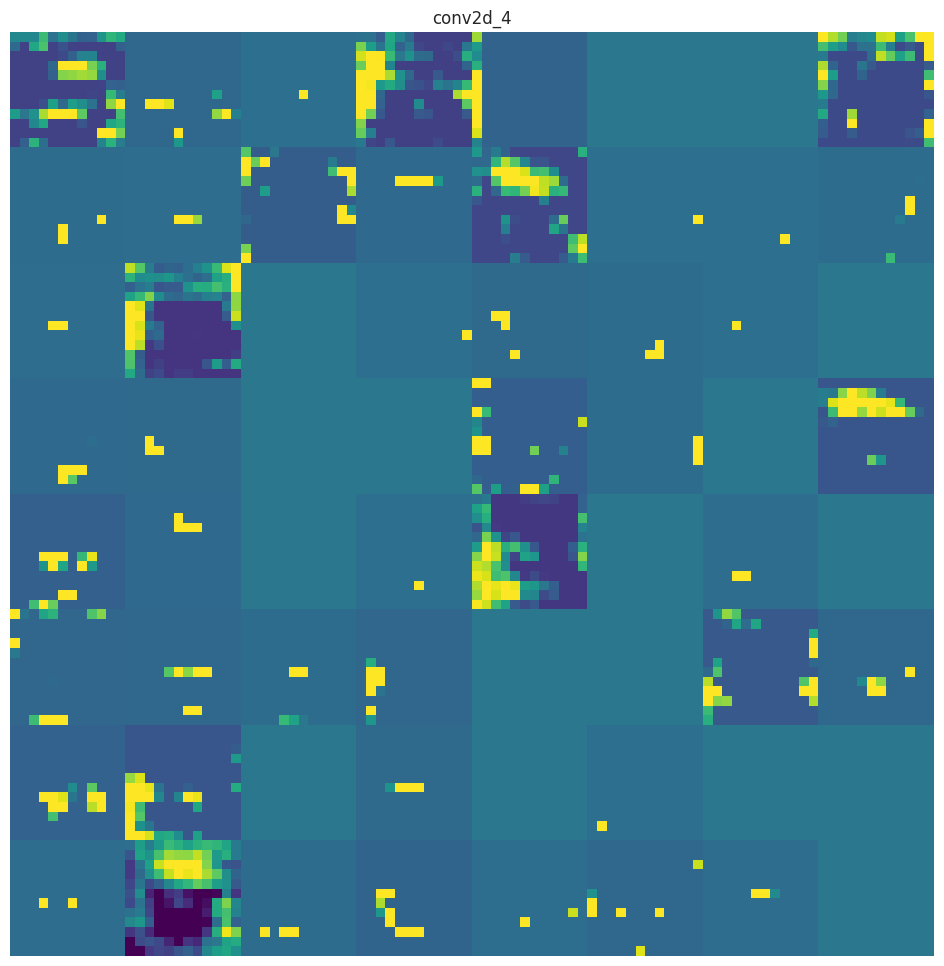

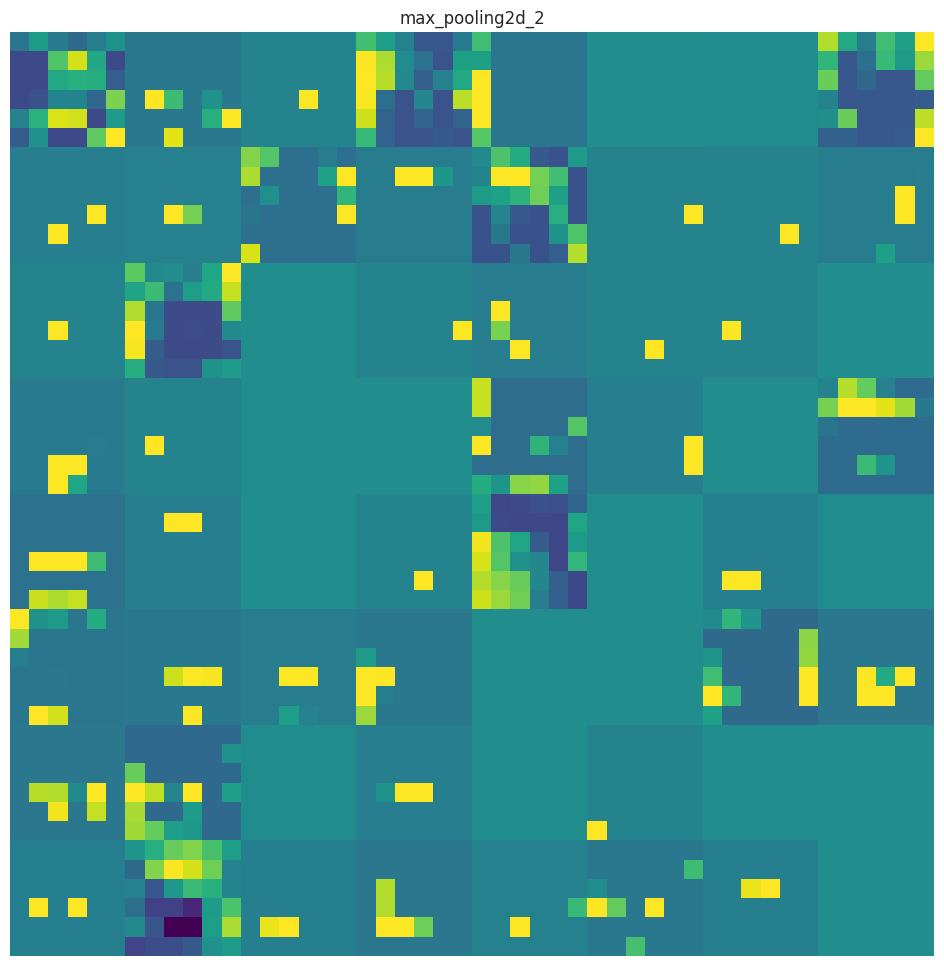

Skipping layer global_average_pooling2d as it is not 4D.


In [ ]:
# Load an input image from your dataset
img_path = '/content/emotion/train/angry/Training_10118481.jpg'
img = image.load_img(img_path, target_size=(48, 48), color_mode='grayscale')
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.  # Normalize to match training preprocessing

# Ensure the model is built by running a dummy prediction (important fix)
# This line was causing issues in some cases, it is better to build the model explicitly
# _ = emotion_model.predict(np.zeros((1, 48, 48, 1)))

# Explicitly build the model by calling it with dummy input
if not emotion_model.built:
    emotion_model(np.zeros((1, 48, 48, 1)))


# Extract outputs of all conv and pooling layers
layer_outputs = [layer.output for layer in emotion_model.layers if 'conv' in layer.name or 'pool' in layer.name]
layer_names = [layer.name for layer in emotion_model.layers if 'conv' in layer.name or 'pool' in layer.name]

# Define a new model to return these intermediate activations
activation_model = Model(inputs=emotion_model.input, outputs=layer_outputs)

# Run inference to get feature maps
activations = activation_model.predict(img_tensor)

# Helper function to plot the activations
def display_activations(activations, layer_names):
    for layer_name, activation in zip(layer_names, activations):
        # Check if activation is 4D before accessing channels
        if activation.ndim == 4:
            num_features = activation.shape[-1]
            size = activation.shape[1]

            # Display only first 64 channels or fewer if not available
            display_channels = min(64, num_features)
            cols = 8
            rows = display_channels // cols

            display_grid = np.zeros((size * rows, size * cols))

            for i in range(rows):
                for j in range(cols):
                    idx = i * cols + j
                    channel_image = activation[0, :, :, idx]
                    channel_image -= channel_image.mean()
                    channel_image /= (channel_image.std() + 1e-5)
                    channel_image *= 64
                    channel_image += 128
                    channel_image = np.clip(channel_image, 0, 255).astype('uint8')
                    display_grid[i * size : (i + 1) * size, j * size : (j + 1) * size] = channel_image

            plt.figure(figsize=(12, 12))
            plt.title(layer_name)
            plt.grid(False)
            plt.imshow(display_grid, cmap='viridis')
            plt.axis('off')
            plt.show()
        else:
            print(f"Skipping layer {layer_name} as it is not 4D.")


# Plot the activations
display_activations(activations, layer_names)